In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("Courses.csv")
df.head()

Saving Courses.csv to Courses.csv


,index,Random,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,86,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,...,0,12/19/2012,11/17/2013,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,7,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,...,0,10/15/2012,NaN,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,70,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,...,0,2/8/2013,11/17/2013,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,60,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,...,0,9/17/2012,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,3,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,...,0,12/19/2012,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0


In [3]:
df.shape

(641138, 22)

In [4]:
df[['registered','viewed','explored','certified']].sum()

,0
registered,641138
viewed,400262
explored,39686
certified,17687


In [5]:
df.groupby('certified')[['nevents','ndays_act','nchapters']].mean()

,nevents,ndays_act,nchapters
certified,,,
0,233.882523,4.129643,3.00008
1,5163.269024,46.910778,16.71431


In [6]:
df[df['incomplete_flag'] == 1][['nevents','ndays_act']].mean()

,0
nevents,NaN
ndays_act,4.390189


In [7]:
df[df['incomplete_flag'] == 1][['nevents','ndays_act']].mean()

,0
nevents,NaN
ndays_act,4.390189


In [8]:
df.groupby('certified')['nforum_posts'].mean()

,nforum_posts
certified,
0,0.013513
1,0.211229


In [9]:
cols = ['grade', 'nevents', 'nchapters']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [10]:
df[cols] = df[cols].fillna(0)

In [11]:
df[cols].corr()

,grade,nevents,nchapters
grade,1.000000,0.702796,0.695194
nevents,0.702796,1.000000,0.609376
nchapters,0.695194,0.609376,1.000000


In [12]:
df.to_csv("cleaned_data.csv", index=False)

In [13]:
df_cleaned = pd.read_csv('cleaned_data.csv')
df_cleaned.head()

,index,Random,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,...,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,86,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,...,0.0,12/19/2012,11/17/2013,0.0,9.0,NaN,0.0,0,NaN,1.0
1,1,7,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,...,0.0,10/15/2012,NaN,0.0,9.0,NaN,1.0,0,NaN,1.0
2,2,70,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,...,0.0,2/8/2013,11/17/2013,0.0,16.0,NaN,0.0,0,NaN,1.0
3,3,60,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,...,0.0,9/17/2012,NaN,0.0,16.0,NaN,0.0,0,NaN,1.0
4,4,3,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,...,0.0,12/19/2012,NaN,0.0,16.0,NaN,0.0,0,NaN,1.0


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
total_users = len(df)
completion_rate = df['certified'].mean()
avg_grade_certified = df[df['certified'] == 1]['grade'].mean()

print("Total Users:", total_users)
print("Completion Rate:", round(completion_rate * 100, 2), "%")
print("Avg Grade (Certified):", round(avg_grade_certified * 100, 2), "%")

Total Users: 641138
Completion Rate: 2.76 %
Avg Grade (Certified): 83.56 %


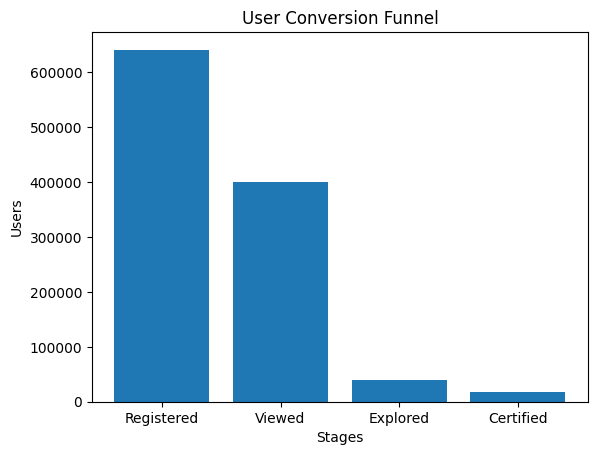

In [16]:
funnel = {
    "Registered": df['registered'].sum(),
    "Viewed": df['viewed'].sum(),
    "Explored": df['explored'].sum(),
    "Certified": df['certified'].sum()
}

plt.figure()
plt.bar(funnel.keys(), funnel.values())
plt.title("User Conversion Funnel")
plt.xlabel("Stages")
plt.ylabel("Users")
plt.show()

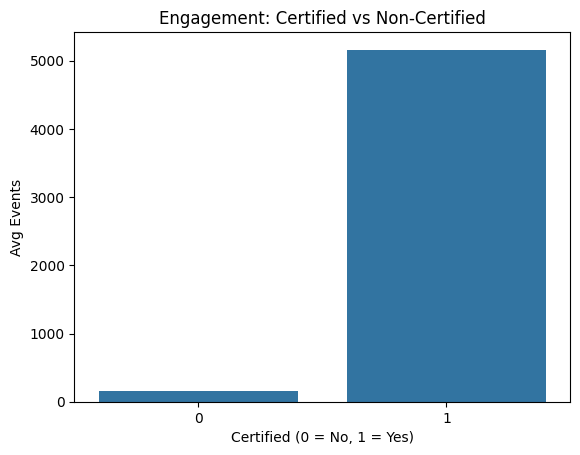

In [17]:
engagement = df.groupby('certified')[['nevents']].mean().reset_index()

plt.figure()
sns.barplot(x='certified', y='nevents', data=engagement)
plt.title("Engagement: Certified vs Non-Certified")
plt.xlabel("Certified (0 = No, 1 = Yes)")
plt.ylabel("Avg Events")
plt.show()

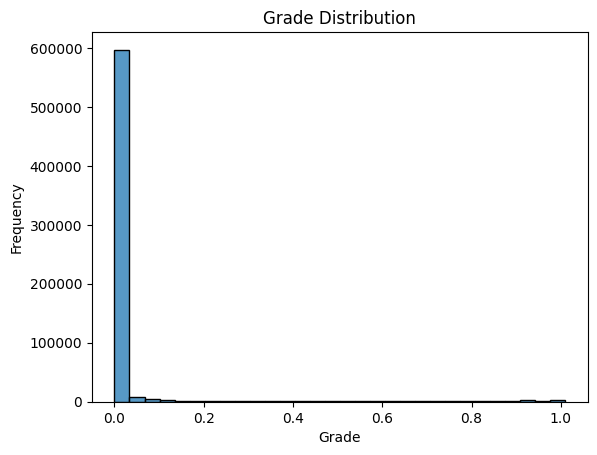

In [18]:
plt.figure()
sns.histplot(df['grade'], bins=30)
plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Frequency")
plt.show()

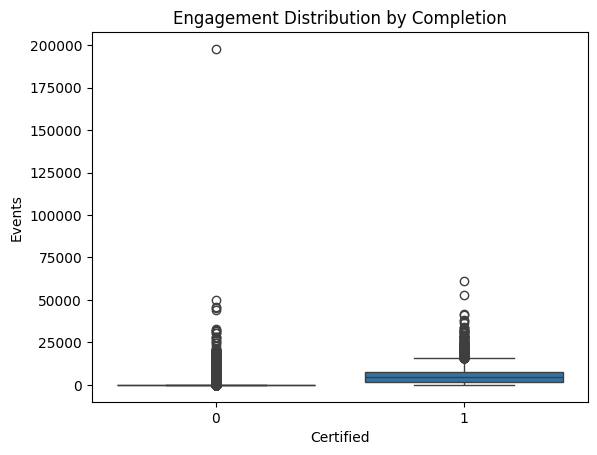

In [19]:
plt.figure()
sns.boxplot(x='certified', y='nevents', data=df)
plt.title("Engagement Distribution by Completion")
plt.xlabel("Certified")
plt.ylabel("Events")
plt.show()

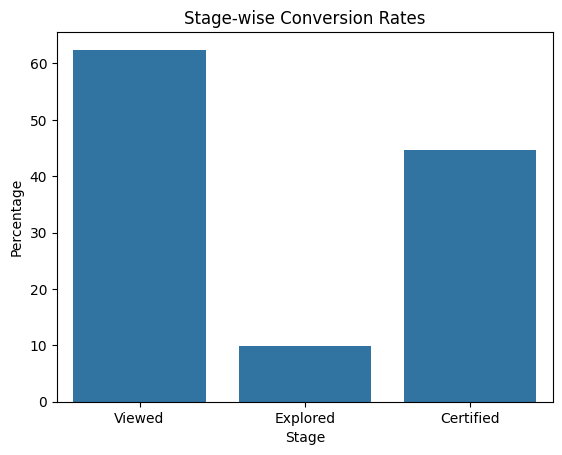

In [20]:
dropoff = [
    ("Viewed", df['viewed'].sum()/df['registered'].sum()*100),
    ("Explored", df['explored'].sum()/df['viewed'].sum()*100),
    ("Certified", df['certified'].sum()/df['explored'].sum()*100)
]

drop_df = pd.DataFrame(dropoff, columns=['Stage', 'Conversion %'])

plt.figure()
sns.barplot(x='Stage', y='Conversion %', data=drop_df)
plt.title("Stage-wise Conversion Rates")
plt.ylabel("Percentage")
plt.show()